# Zusammenfassung der Analyse

## Datengrundlage

Ausgangspunkt der Analyse war ein Datensatz mit insgesamt **7.618 Preprints** aus dem Bereich der Neurowissenschaften. Für die Untersuchung des wissenschaftlichen Erfolgs wurden zusätzlich Zitationsdaten über die Semantic-Scholar-API abgerufen.

Für **5.025 Dokumente (65,97 %)** konnten erfolgreich Zitationsinformationen ermittelt werden. Da die Anzahl der Zitierungen als Erfolgsvariable definiert wurde, wurden ausschließlich diese Dokumente für die weiteren Analysen berücksichtigt.

---

## Ziel der Analyse

Ziel dieser Untersuchung war es zu analysieren, ob sprachliche und strukturelle Eigenschaften wissenschaftlicher Preprints mit ihrem späteren wissenschaftlichen Erfolg zusammenhängen.

Als Erfolgsmaß wurde die Anzahl der Zitierungen (`citation_count`) verwendet. Aufgrund der stark rechtsschiefen Verteilung der Zitierungen wurde zusätzlich eine logarithmische Transformation (`log_citations`) für die statistischen Analysen verwendet.

---

## Sprachliche Merkmale

Zur Beschreibung der sprachlichen Komplexität wurden verschiedene Lesbarkeitsmetriken berechnet, darunter:

- Gunning Fog Index
- Flesch Reading Ease
- Durchschnittliche Satzlänge
- Wortanzahl

Anschließend wurden die Top 10 % der meistzitierten Papers als **High-Impact-Papers** definiert und mit den übrigen Dokumenten verglichen.

Die durchgeführten Welch-t-Tests ergaben keine statistisch signifikanten Unterschiede für die Lesbarkeitsmetriken:

| Merkmal | p-Wert |
|----------|----------|
| Gunning Fog | 0.230 |
| Flesch Reading Ease | 0.166 |

Die Ergebnisse deuten darauf hin, dass die sprachliche Komplexität eines Papers keinen messbaren Einfluss auf dessen wissenschaftlichen Erfolg besitzt.

---

## Strukturelle Merkmale

Zusätzlich wurden verschiedene strukturelle Eigenschaften der Dokumente analysiert:

- Anzahl der Referenzen (`reference_count`)
- Anzahl der Abbildungen (`figure_count`)
- Anzahl der Abschnitte (`section_count`)
- Anzahl der Tabellen (`table_count`)

Die Signifikanztests zeigten statistisch signifikante Unterschiede zwischen High-Impact- und Low-Impact-Papers für folgende Merkmale:

| Merkmal | p-Wert |
|----------|----------|
| Referenzen | 0.0018 |
| Abbildungen | 0.0116 |
| Wortanzahl | 0.0171 |

Keine signifikanten Unterschiede wurden für die Anzahl der Abschnitte festgestellt.

Die Boxplots zeigten darüber hinaus, dass hoch zitierte Papers tendenziell mehr Referenzen und mehr Abbildungen enthalten als weniger zitierte Papers.

---

## Korrelationsanalyse

Zur Untersuchung linearer Zusammenhänge wurden Pearson-Korrelationen zwischen den Strukturmerkmalen und den logarithmierten Zitierungen berechnet.

| Merkmal | Korrelation mit log_citations |
|----------|----------|
| Referenzen | 0.082 |
| Abbildungen | 0.069 |
| Abschnitte | 0.058 |
| Tabellen | 0.024 |

Obwohl die Zusammenhänge statistisch nachweisbar sind, fallen die Effektstärken insgesamt gering aus.

Dies deutet darauf hin, dass strukturelle Merkmale zwar mit dem wissenschaftlichen Erfolg eines Papers zusammenhängen, jedoch nur einen kleinen Teil der Unterschiede in den Zitierhäufigkeiten erklären.

---

## Fazit

Die Analyse zeigt, dass strukturelle Eigenschaften wissenschaftlicher Preprints stärker mit ihrem späteren Erfolg zusammenhängen als klassische Lesbarkeitsmetriken.

Insbesondere Papers mit einer höheren Anzahl an Referenzen, Abbildungen und Wörtern weisen tendenziell höhere Zitierhäufigkeiten auf. Die sprachliche Komplexität des Textes scheint hingegen keinen signifikanten Einfluss auf den wissenschaftlichen Erfolg zu besitzen.

Insgesamt legen die Ergebnisse nahe, dass Umfang und strukturelle Ausgestaltung eines Papers wichtiger für dessen Sichtbarkeit und Rezeption sind als seine sprachliche Lesbarkeit. Gleichzeitig zeigen die vergleichsweise schwachen Korrelationen, dass weitere Faktoren außerhalb des eigentlichen Dokumentaufbaus eine wesentliche Rolle für den wissenschaftlichen Erfolg spielen.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../output/final_dataset.csv",
    sep=";"
)


### Auswahl des finalen Datensatzes

Der ursprüngliche Datensatz umfasste 7.618 Preprints. Für 5.025 Dokumente konnten über Semantic Scholar erfolgreich Zitationsdaten abgerufen werden. Da die Zitierhäufigkeit die zentrale Erfolgsvariable dieser Analyse darstellt, wurden ausschließlich diese Dokumente für die weiteren Auswertungen berücksichtigt.

Insgesamt konnten somit für 65,97 % der ursprünglichen Dokumente Zitationsinformationen ermittelt werden. Die verbleibenden Dokumente wurden aufgrund fehlender oder nicht verfügbarer Zitationsdaten von der Analyse ausgeschlossen.

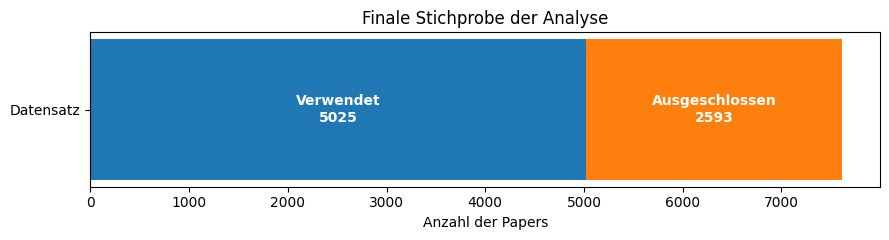

In [32]:
import matplotlib.pyplot as plt

total_papers = 7618
used_papers = 5025
excluded_papers = total_papers - used_papers

plt.figure(figsize=(9, 2.5))

plt.barh(
    ["Datensatz"],
    [used_papers]
)

plt.barh(
    ["Datensatz"],
    [excluded_papers],
    left=[used_papers]
)

# Text in die Balken schreiben
plt.text(
    used_papers / 2,
    0,
    f"Verwendet\n{used_papers}",
    ha="center",
    va="center",
    color="white",
    fontweight="bold"
)

plt.text(
    used_papers + excluded_papers / 2,
    0,
    f"Ausgeschlossen\n{excluded_papers}",
    ha="center",
    va="center",
    color="white",
    fontweight="bold"
)

plt.xlabel("Anzahl der Papers")
plt.title("Finale Stichprobe der Analyse")

plt.tight_layout()
plt.show()

In [7]:
df.shape

df.info()

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 5025 entries, 0 to 5024
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_count                  5025 non-null   int64  
 1   sentence_count              5025 non-null   int64  
 2   flesch_reading_ease         5025 non-null   float64
 3   gunning_fog                 5025 non-null   float64
 4   flesch_kincaid_grade        5025 non-null   float64
 5   avg_sentence_length         5025 non-null   float64
 6   avg_letter_per_word         5025 non-null   float64
 7   lexicon_count               5025 non-null   int64  
 8   figure_count                5025 non-null   int64  
 9   table_count                 5025 non-null   int64  
 10  section_count               5025 non-null   float64
 11  reference_count             5025 non-null   float64
 12  doi                         5025 non-null   str    
 13  preprint_date               5025 non-null   

,word_count,sentence_count,flesch_reading_ease,gunning_fog,flesch_kincaid_grade,avg_sentence_length,avg_letter_per_word,lexicon_count,figure_count,table_count,section_count,reference_count,published_doi,published_flag,citation_count,influential_citation_count,semantic_year,status
count,5025.000000,5025.000000,5025.000000,5025.000000,5025.000000,5025.000000,5025.000000,5025.000000,5025.000000,5025.000000,5025.000000,5025.000000,0.0,5025.0,5025.000000,5025.000000,5024.000000,5025.0
mean,6394.630249,319.223881,31.972580,16.983741,13.842669,20.299152,5.445566,6347.763781,8.168955,1.279403,25.324975,65.578507,NaN,0.0,13.345473,0.742886,2020.543989,200.0
std,2590.155597,137.437681,7.597246,1.647391,1.545849,2.837875,0.227839,2565.224020,5.481141,2.324737,11.107612,30.754891,NaN,0.0,54.465823,4.081129,2.493962,0.0
min,1012.000000,47.000000,0.141000,11.340939,8.623756,11.455645,4.602591,1002.000000,0.000000,0.000000,1.000000,0.000000,NaN,0.0,0.000000,0.000000,2013.000000,200.0
25%,4604.000000,222.000000,27.200091,15.887703,12.807640,18.408369,5.296904,4578.000000,5.000000,0.000000,18.000000,46.000000,NaN,0.0,1.000000,0.000000,2018.000000,200.0
50%,6095.000000,301.000000,32.350374,16.900206,13.759569,20.117871,5.436696,6048.000000,7.000000,0.000000,24.000000,61.000000,NaN,0.0,3.000000,0.000000,2020.000000,200.0
75%,7821.000000,393.000000,37.083393,18.017041,14.786461,21.975550,5.586588,7758.000000,10.000000,2.000000,31.000000,80.000000,NaN,0.0,10.000000,0.000000,2023.000000,200.0
max,24308.000000,1286.000000,59.011748,24.143817,20.922634,34.706806,6.476966,24225.000000,128.000000,59.000000,185.000000,580.000000,NaN,0.0,2326.000000,147.000000,2026.000000,200.0


<Axes: xlabel='citation_count', ylabel='Count'>

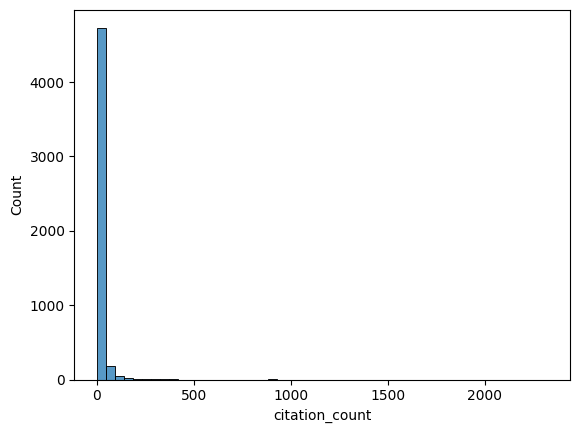

In [8]:
sns.histplot(
    df["citation_count"],
    bins=50
)

In [9]:
df["log_citations"] = np.log1p(
    df["citation_count"]
)

<Axes: xlabel='log_citations', ylabel='Count'>

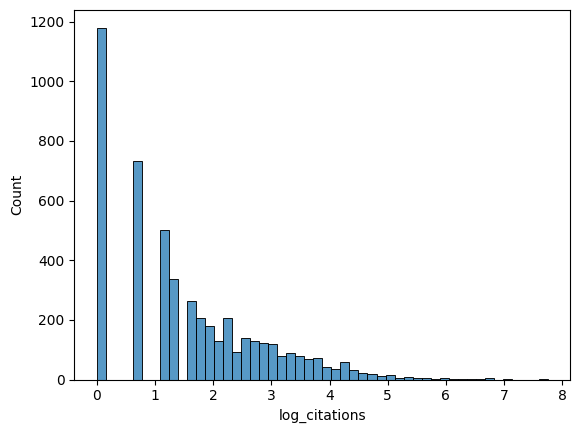

In [10]:
sns.histplot(
    df["log_citations"],
    bins=50
)

In [11]:
corr_cols = [
    "citation_count",
    "gunning_fog",
    "flesch_reading_ease",
    "avg_sentence_length",
    "word_count",
    "reference_count",
    "section_count",
    "figure_count",
    "table_count"
]

Frage 5.1 – Korrelationen

In [12]:
corr_cols = [
    "citation_count",
    "gunning_fog",
    "flesch_reading_ease",
    "avg_sentence_length",
    "word_count",
    "reference_count",
    "section_count",
    "figure_count",
    "table_count"
]

corr_matrix = df[corr_cols].corr()

corr_matrix["citation_count"]\
    .sort_values(ascending=False)

citation_count         1.000000
word_count             0.038520
figure_count           0.037284
reference_count        0.033339
section_count          0.027609
avg_sentence_length    0.026169
gunning_fog            0.015041
table_count            0.008993
flesch_reading_ease   -0.015003
Name: citation_count, dtype: float64

Log citations weil daten extrem schief sind

In [13]:
import numpy as np

df["log_citations"] = np.log1p(
    df["citation_count"]
)

In [14]:
corr_cols = [
    "log_citations",
    "gunning_fog",
    "flesch_reading_ease",
    "avg_sentence_length",
    "word_count",
    "reference_count",
    "section_count",
    "figure_count",
    "table_count"
]

df[corr_cols].corr()["log_citations"]\
    .sort_values(ascending=False)

log_citations          1.000000
word_count             0.097694
reference_count        0.082328
figure_count           0.068890
section_count          0.057745
avg_sentence_length    0.053251
gunning_fog            0.034814
table_count            0.024125
flesch_reading_ease   -0.032350
Name: log_citations, dtype: float64

Frage 6 – Structure vs Success

<Axes: xlabel='reference_count', ylabel='log_citations'>

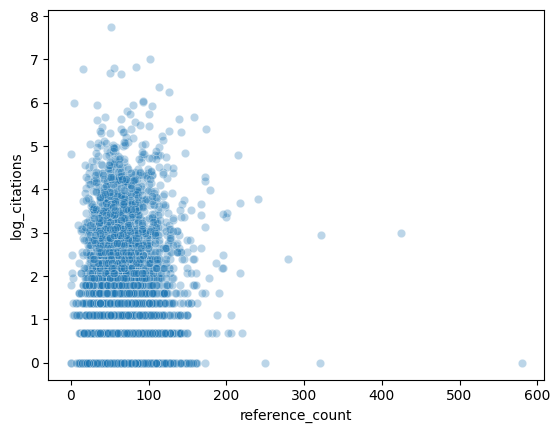

In [15]:
sns.scatterplot(
    data=df,
    x="reference_count",
    y="log_citations",
    alpha=0.3
)

<Axes: xlabel='section_count', ylabel='log_citations'>

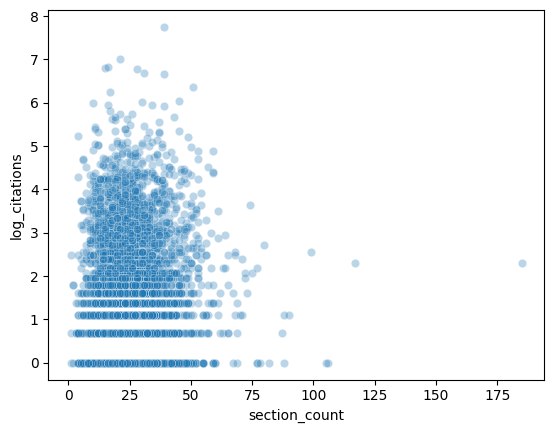

In [16]:
sns.scatterplot(
    data=df,
    x="section_count",
    y="log_citations",
    alpha=0.3
)

<Axes: xlabel='figure_count', ylabel='log_citations'>

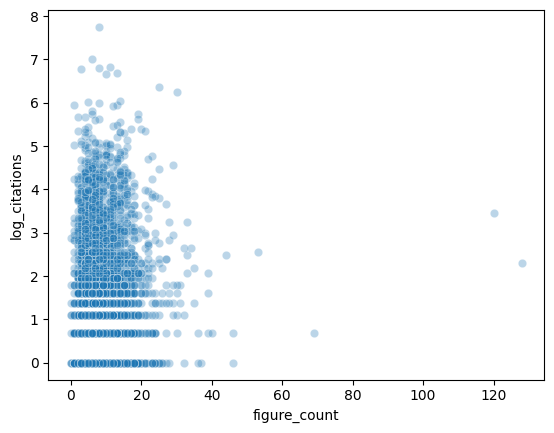

In [17]:
sns.scatterplot(
    data=df,
    x="figure_count",
    y="log_citations",
    alpha=0.3
)

Frage 7 – Top 10 % Papers

In [18]:
threshold = df[
    "citation_count"
].quantile(0.9)

df["high_impact"] = (
    df["citation_count"] >= threshold
).astype(int)

print(threshold)

30.0


In [19]:
df.groupby(
    "high_impact"
)[
    [
        "gunning_fog",
        "flesch_reading_ease",
        "reference_count",
        "section_count",
        "figure_count",
        "word_count"
    ]
].mean()

,gunning_fog,flesch_reading_ease,reference_count,section_count,figure_count,word_count
high_impact,,,,,,
0,16.974785,32.019654,65.106416,25.253982,8.087389,6366.650442
1,17.063907,31.551244,69.803960,25.960396,8.899010,6645.063366


Korrelationen

In [20]:
corr_cols = [
    "log_citations",
    "gunning_fog",
    "flesch_reading_ease",
    "avg_sentence_length",
    "word_count",
    "reference_count",
    "section_count",
    "figure_count",
    "table_count"
]

df[corr_cols].corr()["log_citations"]\
    .sort_values(ascending=False)

log_citations          1.000000
word_count             0.097694
reference_count        0.082328
figure_count           0.068890
section_count          0.057745
avg_sentence_length    0.053251
gunning_fog            0.034814
table_count            0.024125
flesch_reading_ease   -0.032350
Name: log_citations, dtype: float64

Signifikantstest

In [21]:
from scipy.stats import ttest_ind

low = df[
    df["high_impact"] == 0
]["reference_count"]

high = df[
    df["high_impact"] == 1
]["reference_count"]

ttest_ind(
    low,
    high,
    equal_var=False
)

TtestResult(statistic=np.float64(-3.1302077794008336), pvalue=np.float64(0.0018302600187055807), df=np.float64(610.2954243036974))

Inhaltlich Signifikantstest Ergebnis:

Die zuvor beobachtete Differenz:

65.1 Referenzen
vs.
69.8 Referenzen

ist wahrscheinlich kein Zufall.

Vielmehr deutet das Ergebnis darauf hin, dass:

Hoch zitierte Papers im Durchschnitt mehr Literaturreferenzen enthalten als weniger zitierte Papers.

Der Welch-t-Test zeigt einen statistisch signifikanten Unterschied in der Anzahl der Referenzen zwischen hoch zitierten und weniger zitierten Papers (t = -3.13, p = 0.0018). Hoch zitierte Papers enthalten im Durchschnitt mehr Referenzen.

Welch t-Test für alle restlichen Features 

In [22]:
from scipy.stats import ttest_ind

features = [
    "reference_count",
    "figure_count",
    "section_count",
    "word_count",
    "gunning_fog",
    "flesch_reading_ease"
]

for feature in features:

    low = df[
        df["high_impact"] == 0
    ][feature]

    high = df[
        df["high_impact"] == 1
    ][feature]

    result = ttest_ind(
        low,
        high,
        equal_var=False
    )

    print(
        f"{feature}: "
        f"t={result.statistic:.3f}, "
        f"p={result.pvalue:.5f}"
    )

reference_count: t=-3.130, p=0.00183
figure_count: t=-2.531, p=0.01164
section_count: t=-1.339, p=0.18105
word_count: t=-2.391, p=0.01710
gunning_fog: t=-1.201, p=0.23037
flesch_reading_ease: t=1.386, p=0.16638


Ergebnisse der Signifikanztests

Die durchgeführten Welch-t-Tests zeigen, dass hoch zitierte Papers im Durchschnitt signifikant mehr Referenzen, Abbildungen und Wörter enthalten als weniger zitierte Papers. Für die Merkmale `reference_count` (p = 0,0018), `figure_count` (p = 0,0116) und `word_count` (p = 0,0171) konnten statistisch signifikante Unterschiede festgestellt werden.

Für die Lesbarkeitsmetriken `gunning_fog` und `flesch_reading_ease` sowie die Anzahl der Abschnitte (`section_count`) ergaben sich hingegen keine signifikanten Unterschiede. Dies deutet darauf hin, dass strukturelle Eigenschaften eines Papers stärker mit seinem wissenschaftlichen Erfolg zusammenhängen als die sprachliche Komplexität des Textes.

In [23]:
structure_cols = [
    "reference_count",
    "section_count",
    "figure_count",
    "table_count",
    "log_citations"
]

df[structure_cols].corr()["log_citations"]\
    .sort_values(ascending=False)

log_citations      1.000000
reference_count    0.082328
figure_count       0.068890
section_count      0.057745
table_count        0.024125
Name: log_citations, dtype: float64

<Axes: xlabel='reference_count', ylabel='log_citations'>

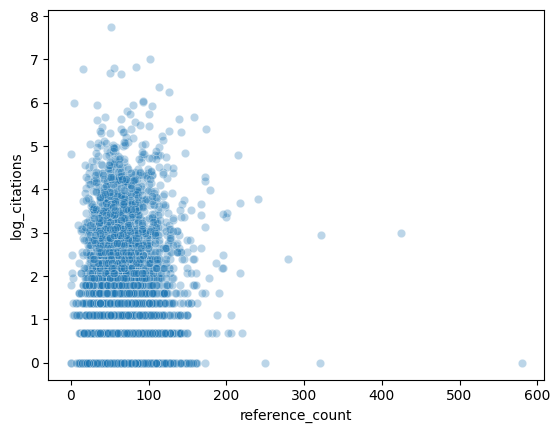

In [24]:
sns.scatterplot(
    data=df,
    x="reference_count",
    y="log_citations",
    alpha=0.3
)

<Axes: xlabel='figure_count', ylabel='log_citations'>

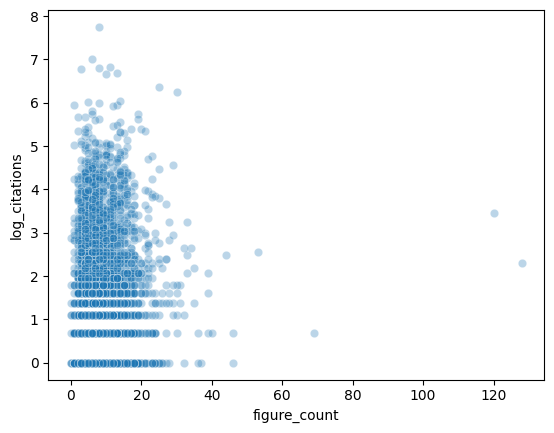

In [25]:
sns.scatterplot(
    data=df,
    x="figure_count",
    y="log_citations",
    alpha=0.3
)

<Axes: xlabel='section_count', ylabel='log_citations'>

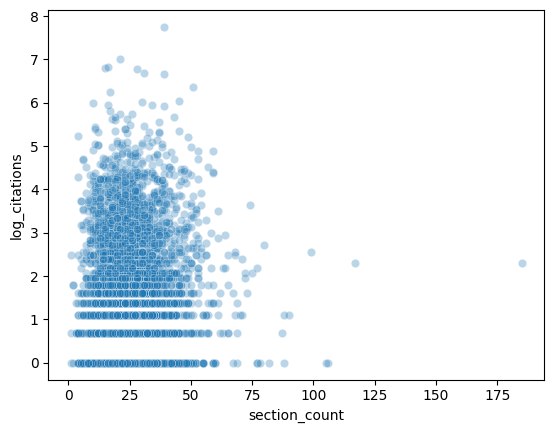

In [26]:
sns.scatterplot(
    data=df,
    x="section_count",
    y="log_citations",
    alpha=0.3
)

Die Scatterplots zeigen keinen ausgeprägten linearen Zusammenhang zwischen den untersuchten Strukturmerkmalen und der Zitierhäufigkeit. Dennoch ist eine leichte positive Tendenz erkennbar, die mit den zuvor identifizierten signifikanten, jedoch schwachen Korrelationen übereinstimmt.

In [27]:
structure_cols = [
    "reference_count",
    "section_count",
    "figure_count",
    "table_count",
    "log_citations"
]

df[structure_cols].corr()["log_citations"]\
    .sort_values(ascending=False)

log_citations      1.000000
reference_count    0.082328
figure_count       0.068890
section_count      0.057745
table_count        0.024125
Name: log_citations, dtype: float64

Wissenschaftliche Interpretation

Eure Ergebnisse deuten darauf hin, dass:

Strukturelle Merkmale einen messbaren Zusammenhang mit dem wissenschaftlichen Erfolg aufweisen.
Die Effektstärke jedoch gering ist.
Der Erfolg eines Papers wahrscheinlich von vielen weiteren Faktoren beeinflusst wird, beispielsweise:
Forschungsgebiet
Aktualität des Themas
Reputation der Autoren
Veröffentlichungsort
wissenschaftliche Qualität

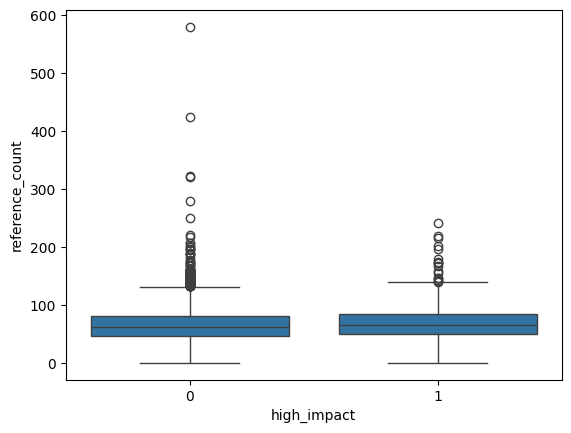

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=df,
    x="high_impact",
    y="reference_count"
)

plt.show()

### Vergleich der Referenzanzahl zwischen High-Impact- und Low-Impact-Papers

Der Boxplot zeigt, dass hoch zitierte Papers im Durchschnitt mehr Literaturreferenzen enthalten als weniger zitierte Papers. Dies wird durch einen leicht höheren Median sowie höhere Quartilswerte der High-Impact-Gruppe sichtbar. Trotz einer starken Überlappung der Verteilungen konnte der Unterschied im vorherigen Welch-t-Test als statistisch signifikant nachgewiesen werden (p = 0,0018).

Die Ergebnisse deuten darauf hin, dass eine stärkere Einbettung in die bestehende Literatur mit einem höheren wissenschaftlichen Erfolg zusammenhängen kann.

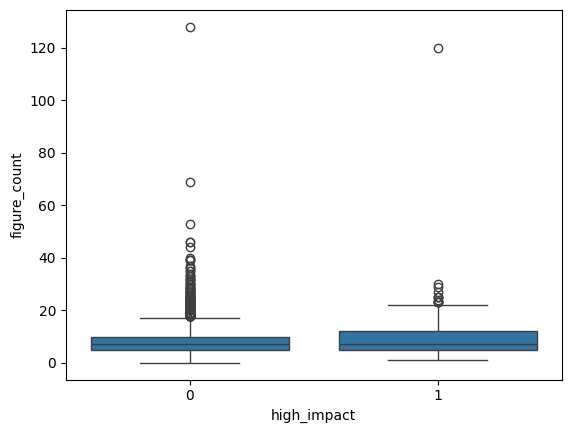

In [29]:
sns.boxplot(
    data=df,
    x="high_impact",
    y="figure_count"
)

plt.show()

### Vergleich der Anzahl von Abbildungen zwischen High-Impact- und Low-Impact-Papers

Der Boxplot zeigt, dass hoch zitierte Papers tendenziell mehr Abbildungen enthalten als weniger zitierte Papers. Die Verteilung der High-Impact-Gruppe ist leicht nach oben verschoben, was sich insbesondere im höheren Median widerspiegelt. Auch dieser Unterschied wurde im Welch-t-Test als statistisch signifikant identifiziert (p = 0,0116).

Dies deutet darauf hin, dass eine stärkere visuelle Aufbereitung wissenschaftlicher Inhalte mit einer höheren Zitierhäufigkeit verbunden sein kann. Der Effekt fällt jedoch insgesamt eher gering aus.